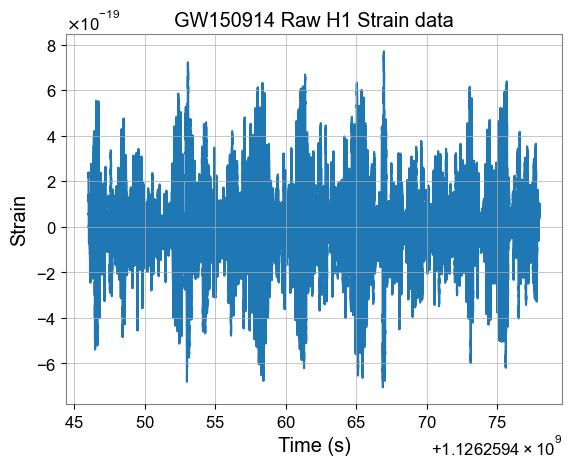

In [4]:
import numpy as np
import math
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

h1data = TimeSeries.fetch_open_data("H1", 1126259446 , 1126259478)

plt.plot(h1data.times.value, h1data.value)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("GW150914 Raw H1 Strain data")
plt.show()

Above is the raw data from H1, the gravitational waves are expected to be hiding in all the noise. To find the signal, all of the background noise needs to be whitened. The noise blocking the wanted data is from various sources, including thermal noise on the mirrors, seismic noise from tectonic plate movements, and many others. 

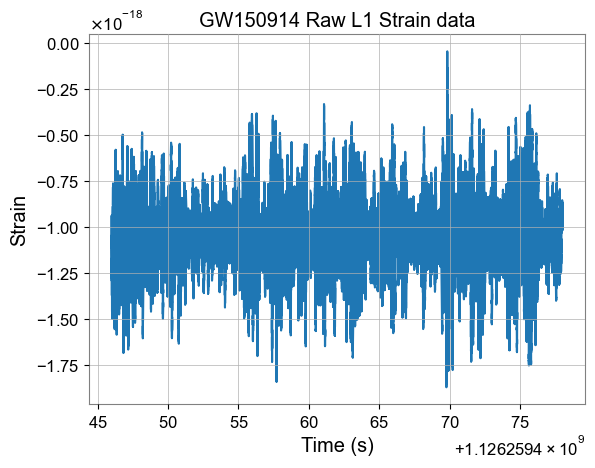

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

l1data = TimeSeries.fetch_open_data("L1", 1126259446 , 1126259478)

plt.plot(l1data.times.value, l1data.value)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("GW150914 Raw L1 Strain data")
plt.show()

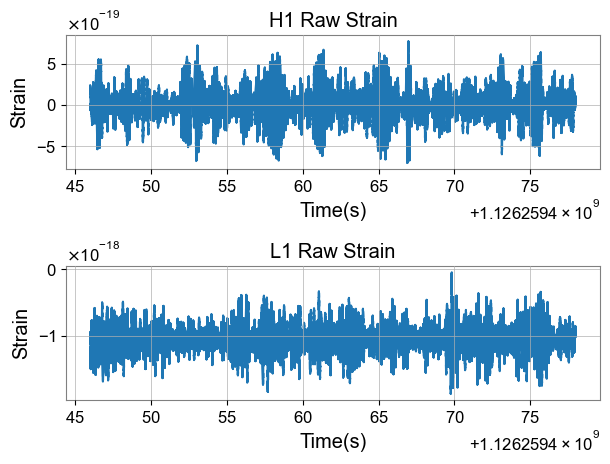

In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries


fig , axes = plt.subplots(2,1)
axes[0].plot(h1data.times.value, h1data.value)
axes[0].set_xlabel("Time(s)")
axes[0].set_ylabel("Strain")
axes[0].set_title("H1 Raw Strain")

axes[1].plot(l1data.times.value, l1data.value)
axes[1].set_xlabel("Time(s)")
axes[1].set_ylabel("Strain")
axes[1].set_title("L1 Raw Strain")

plt.tight_layout(h1data)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

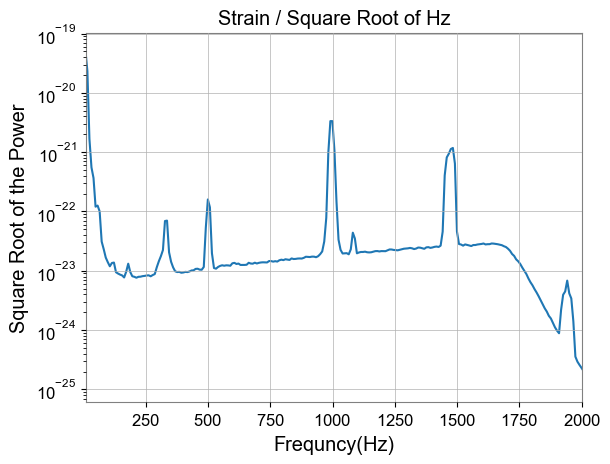

In [12]:
import numpy as np
import math
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from scipy.signal import welch

h1_array = np.array(h1data.value)
freqs , power = welch(h1_array, fs=4096, nperseg=500)
asd_power = np.sqrt(power)

plt.plot(freqs, asd_power)
plt.xlabel("Frequncy(Hz)")
plt.xlim(10,2000)
plt.yscale("log")
plt.ylabel("Square Root of the Power")
plt.title("Strain / Square Root of Hz")
plt.show

Above is the plot of the ASD of the H1 data from GW150914. The spike on the left side of the graph is a result of constant seismic movement, 